In [1]:
from __future__ import annotations

import gc
import os
import sqlite3
import subprocess
import threading
import time
from pathlib import Path
from typing import Any, Callable

import gffutils
import matplotlib.pyplot as plt
import polars as pl
import psutil

from griffith import Griffith

In [4]:
GTF_PATH = Path("../tests/data/gencode.v50.chr_patch_hapl_scaff.basic.annotation.gtf")

DATASET_NAME = "GENCODE_v50_chr_patch_hapl_scaff_basic"
DIALECT = "gtf"

BENCHMARK_DIR = Path("benchmark_gencode_v50_griffith_vs_gffutils")
OUT_DIR = BENCHMARK_DIR / "results"
DB_DIR = BENCHMARK_DIR / "db"

OUT_DIR.mkdir(parents=True, exist_ok=True)
DB_DIR.mkdir(parents=True, exist_ok=True)

GFFUTILS_DB = DB_DIR / "gencode_v50_basic.gffutils.db"

GENCODE_ATTRIBUTES = [
    "gene_id",
    "gene_type",
    "gene_name",
    "level",
    "hgnc_id",
    "havana_gene",
    "transcript_id",
    "transcript_type",
    "transcript_name",
    "transcript_support_level",
    "tag",
    "havana_transcript",
    "exon_number",
    "exon_id",
    "protein_id",
    "ccdsid",
    "ont",
]

In [5]:
assert GTF_PATH.exists(), f"Missing file: {GTF_PATH}"

def file_size_mb(path: Path) -> float:
    return path.stat().st_size / 1024**2


file_info = pl.DataFrame(
    [
        {
            "dataset": DATASET_NAME,
            "path": str(GTF_PATH),
            "dialect": DIALECT,
            "file_size_mb": file_size_mb(GTF_PATH),
        }
    ]
)

file_info

dataset,path,dialect,file_size_mb
str,str,str,f64
"""GENCODE_v50_chr_patch_hapl_sca…","""../tests/data/gencode.v50.chr_…","""gtf""",3109.718218


In [6]:
def benchmark_operation(
    tool: str,
    operation: str,
    func: Callable[[], Any],
    *,
    sample_interval: float = 0.05,
) -> tuple[dict[str, Any], Any]:
    """
    Benchmark a single operation.

    Tracks:
    - wall time
    - RSS memory before/after
    - peak RSS memory during execution
    - success/failure
    """
    gc.collect()

    process = psutil.Process(os.getpid())
    rss_before = process.memory_info().rss / 1024**2

    stop_event = threading.Event()
    rss_samples: list[float] = []

    def sample_memory() -> None:
        while not stop_event.is_set():
            rss_samples.append(process.memory_info().rss / 1024**2)
            time.sleep(sample_interval)

    sampler = threading.Thread(target=sample_memory)
    sampler.start()

    t0 = time.perf_counter()
    success = True
    error = None
    result = None

    try:
        result = func()
    except Exception as exc:
        success = False
        error = repr(exc)
    finally:
        elapsed = time.perf_counter() - t0
        stop_event.set()
        sampler.join()

    rss_after = process.memory_info().rss / 1024**2
    peak_rss = max(rss_samples + [rss_before, rss_after])

    record = {
        "dataset": DATASET_NAME,
        "tool": tool,
        "operation": operation,
        "success": success,
        "wall_time_sec": elapsed,
        "rss_before_mb": rss_before,
        "rss_after_mb": rss_after,
        "peak_rss_mb": peak_rss,
        "rss_delta_mb": rss_after - rss_before,
        "peak_rss_delta_mb": peak_rss - rss_before,
        "error": error,
    }

    return record, result

In [7]:
def griffith_load() -> Griffith:
    return Griffith.from_file(
        GTF_PATH,
        dialect="gtf",
        attribute_columns=GENCODE_ATTRIBUTES,
    )


def griffith_count_rows(gf: Griffith) -> int:
    return (
        gf.frame
        .select(pl.len().alias("n"))
        .collect()
        .item()
    )


def griffith_feature_counts(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .group_by("feature")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .collect()
    )


def griffith_attribute_completeness(gf: Griffith, total_rows: int) -> pl.DataFrame:
    schema_names = set(gf.frame.collect_schema().names())

    attrs = [
        attr
        for attr in GENCODE_ATTRIBUTES
        if attr in schema_names
    ]

    row = (
        gf.frame
        .select(
            [
                pl.col(attr).is_not_null().sum().alias(attr)
                for attr in attrs
            ]
        )
        .collect()
    )

    records = []

    for attr in attrs:
        n_non_null = int(row[attr][0])
        records.append(
            {
                "attribute": attr,
                "n_non_null": n_non_null,
                "fraction_non_null": n_non_null / total_rows if total_rows else 0.0,
            }
        )

    return (
        pl.DataFrame(records)
        .sort("fraction_non_null", descending=True)
    )


def griffith_gene_type_counts(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .filter(
            (pl.col("feature") == "gene")
            & pl.col("gene_type").is_not_null()
        )
        .group_by("gene_type")
        .agg(pl.len().alias("n_genes"))
        .sort("n_genes", descending=True)
        .collect()
    )


def griffith_transcript_type_counts(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .filter(
            (pl.col("feature") == "transcript")
            & pl.col("transcript_type").is_not_null()
        )
        .group_by("transcript_type")
        .agg(pl.len().alias("n_transcripts"))
        .sort("n_transcripts", descending=True)
        .collect()
    )


def griffith_exon_counts_per_transcript(gf: Griffith) -> pl.DataFrame:
    return (
        gf.frame
        .filter(
            (pl.col("feature") == "exon")
            & pl.col("transcript_id").is_not_null()
        )
        .group_by("transcript_id")
        .agg(
            pl.len().alias("n_exons"),
            pl.first("gene_id").alias("gene_id"),
            pl.first("gene_name").alias("gene_name"),
            pl.first("transcript_name").alias("transcript_name"),
            pl.first("transcript_type").alias("transcript_type"),
        )
        .sort("n_exons", descending=True)
        .collect()
    )


def griffith_dmd_locus_subset(gf: Griffith) -> Griffith:
    return gf.filter(
        (pl.col("seqid") == "chrX")
        & (pl.col("start") <= 33_300_000)
        & (pl.col("end") >= 31_000_000)
    )


def griffith_dmd_gene_only_subset(gf: Griffith) -> Griffith:
    return gf.filter(
        (pl.col("gene_name") == "DMD")
        | (pl.col("gene_id").str.starts_with("ENSG00000198947"))
    )


def griffith_write_gtf_no_extra_quotes(gf: Griffith, out_path: Path) -> None:
    gf.to_gff(rebuild_attributes=True).sink_csv(
        out_path,
        separator="\t",
        include_header=False,
        quote_style="never",
    )

In [8]:
def gffutils_create_database(force: bool = False) -> gffutils.FeatureDB:
    """
    Create or open a gffutils SQLite database.

    disable_infer_genes=True and disable_infer_transcripts=True are used because
    GENCODE already contains gene and transcript rows.
    """
    if force or not GFFUTILS_DB.exists():
        db = gffutils.create_db(
            str(GTF_PATH),
            dbfn=str(GFFUTILS_DB),
            force=True,
            keep_order=True,
            merge_strategy="merge",
            sort_attribute_values=True,
            disable_infer_genes=True,
            disable_infer_transcripts=True,
            verbose=False,
        )
    else:
        db = gffutils.FeatureDB(
            str(GFFUTILS_DB),
            keep_order=True,
        )

    return db


def gffutils_open_database() -> gffutils.FeatureDB:
    return gffutils.FeatureDB(
        str(GFFUTILS_DB),
        keep_order=True,
    )


def gffutils_count_rows_sql(db_path: Path) -> int:
    with sqlite3.connect(db_path) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT COUNT(*) FROM features")
        return int(cursor.fetchone()[0])


def gffutils_feature_counts_sql(db_path: Path) -> pl.DataFrame:
    with sqlite3.connect(db_path) as conn:
        cursor = conn.cursor()
        cursor.execute(
            """
            SELECT featuretype, COUNT(*)
            FROM features
            GROUP BY featuretype
            ORDER BY COUNT(*) DESC
            """
        )
        rows = cursor.fetchall()

    return pl.DataFrame(
        rows,
        schema=["feature", "n"],
        orient="row",
    )


def _attr_first(feature: gffutils.Feature, key: str) -> str | None:
    value = feature.attributes.get(key)

    if value is None:
        return None

    if isinstance(value, list):
        if not value:
            return None
        return str(value[0])

    return str(value)


def gffutils_gene_type_counts(db: gffutils.FeatureDB) -> pl.DataFrame:
    counts: dict[str, int] = {}

    for feature in db.features_of_type("gene"):
        gene_type = _attr_first(feature, "gene_type")
        if gene_type is None:
            continue
        counts[gene_type] = counts.get(gene_type, 0) + 1

    return (
        pl.DataFrame(
            [{"gene_type": key, "n_genes": value} for key, value in counts.items()]
        )
        .sort("n_genes", descending=True)
    )


def gffutils_transcript_type_counts(db: gffutils.FeatureDB) -> pl.DataFrame:
    counts: dict[str, int] = {}

    for feature in db.features_of_type("transcript"):
        tx_type = _attr_first(feature, "transcript_type")
        if tx_type is None:
            continue
        counts[tx_type] = counts.get(tx_type, 0) + 1

    return (
        pl.DataFrame(
            [
                {"transcript_type": key, "n_transcripts": value}
                for key, value in counts.items()
            ]
        )
        .sort("n_transcripts", descending=True)
    )


def gffutils_exon_counts_per_transcript(db: gffutils.FeatureDB) -> pl.DataFrame:
    """
    Counts exons per transcript using transcript_id attributes.

    This mirrors the Griffith dataframe grouping rather than relying only on
    inferred parent-child relations.
    """
    counts: dict[str, dict[str, Any]] = {}

    for exon in db.features_of_type("exon"):
        transcript_id = _attr_first(exon, "transcript_id")
        if transcript_id is None:
            continue

        if transcript_id not in counts:
            counts[transcript_id] = {
                "transcript_id": transcript_id,
                "n_exons": 0,
                "gene_id": _attr_first(exon, "gene_id"),
                "gene_name": _attr_first(exon, "gene_name"),
            }

        counts[transcript_id]["n_exons"] += 1

    return (
        pl.DataFrame(list(counts.values()))
        .sort("n_exons", descending=True)
    )


def gffutils_dmd_locus_features(db: gffutils.FeatureDB) -> list[gffutils.Feature]:
    return list(
        db.region(
            seqid="chrX",
            start=31_000_000,
            end=33_300_000,
            completely_within=False,
        )
    )


def gffutils_dmd_gene_only_features(db: gffutils.FeatureDB) -> list[gffutils.Feature]:
    features = []

    for feature in db.all_features():
        gene_name = _attr_first(feature, "gene_name")
        gene_id = _attr_first(feature, "gene_id")

        if gene_name == "DMD" or (gene_id is not None and gene_id.startswith("ENSG00000198947")):
            features.append(feature)

    return features


def gffutils_features_to_polars(features: list[gffutils.Feature]) -> pl.DataFrame:
    rows = []

    for feature in features:
        rows.append(
            {
                "seqid": feature.seqid,
                "source": feature.source,
                "feature": feature.featuretype,
                "start": int(feature.start),
                "end": int(feature.end),
                "score": feature.score,
                "strand": feature.strand,
                "phase": feature.frame,
                "gene_id": _attr_first(feature, "gene_id"),
                "gene_name": _attr_first(feature, "gene_name"),
                "gene_type": _attr_first(feature, "gene_type"),
                "transcript_id": _attr_first(feature, "transcript_id"),
                "transcript_name": _attr_first(feature, "transcript_name"),
                "transcript_type": _attr_first(feature, "transcript_type"),
                "exon_number": _attr_first(feature, "exon_number"),
                "exon_id": _attr_first(feature, "exon_id"),
            }
        )

    if not rows:
        return pl.DataFrame()

    return pl.DataFrame(rows)


def gffutils_write_features(features: list[gffutils.Feature], out_path: Path) -> None:
    with out_path.open("w") as handle:
        for feature in features:
            handle.write(str(feature))
            handle.write("\n")

In [9]:
metrics_records = []

rec, gf = benchmark_operation(
    "Griffith",
    "load_lazy_frame",
    griffith_load,
)
metrics_records.append(rec)

if not rec["success"]:
    raise RuntimeError(rec["error"])

rec, griffith_n_rows = benchmark_operation(
    "Griffith",
    "count_rows",
    lambda: griffith_count_rows(gf),
)
metrics_records.append(rec)

rec, griffith_feature_counts = benchmark_operation(
    "Griffith",
    "feature_counts",
    lambda: griffith_feature_counts(gf),
)
metrics_records.append(rec)

rec, griffith_attr_comp = benchmark_operation(
    "Griffith",
    "attribute_completeness",
    lambda: griffith_attribute_completeness(gf, griffith_n_rows),
)
metrics_records.append(rec)

rec, griffith_gene_types = benchmark_operation(
    "Griffith",
    "gene_type_counts",
    lambda: griffith_gene_type_counts(gf),
)
metrics_records.append(rec)

rec, griffith_tx_types = benchmark_operation(
    "Griffith",
    "transcript_type_counts",
    lambda: griffith_transcript_type_counts(gf),
)
metrics_records.append(rec)

rec, griffith_exon_counts = benchmark_operation(
    "Griffith",
    "exon_counts_per_transcript",
    lambda: griffith_exon_counts_per_transcript(gf),
)
metrics_records.append(rec)

rec, griffith_dmd_locus = benchmark_operation(
    "Griffith",
    "create_dmd_locus_subset",
    lambda: griffith_dmd_locus_subset(gf),
)
metrics_records.append(rec)

rec, griffith_dmd_locus_rows = benchmark_operation(
    "Griffith",
    "count_dmd_locus_rows",
    lambda: griffith_count_rows(griffith_dmd_locus),
)
metrics_records.append(rec)

rec, griffith_dmd_gene = benchmark_operation(
    "Griffith",
    "create_dmd_gene_only_subset",
    lambda: griffith_dmd_gene_only_subset(gf),
)
metrics_records.append(rec)

rec, griffith_dmd_gene_rows = benchmark_operation(
    "Griffith",
    "count_dmd_gene_only_rows",
    lambda: griffith_count_rows(griffith_dmd_gene),
)
metrics_records.append(rec)

griffith_dmd_locus_out = OUT_DIR / "griffith_DMD_locus.gtf"

rec, _ = benchmark_operation(
    "Griffith",
    "write_dmd_locus_gtf",
    lambda: griffith_write_gtf_no_extra_quotes(griffith_dmd_locus, griffith_dmd_locus_out),
)
metrics_records.append(rec)

In [10]:
rec, gffutils_db = benchmark_operation(
    "gffutils",
    "create_or_open_database",
    lambda: gffutils_create_database(force=False),
)
metrics_records.append(rec)

if not rec["success"]:
    raise RuntimeError(rec["error"])

rec, gffutils_n_rows = benchmark_operation(
    "gffutils",
    "count_rows_sql",
    lambda: gffutils_count_rows_sql(GFFUTILS_DB),
)
metrics_records.append(rec)

rec, gffutils_feature_counts = benchmark_operation(
    "gffutils",
    "feature_counts_sql",
    lambda: gffutils_feature_counts_sql(GFFUTILS_DB),
)
metrics_records.append(rec)

rec, gffutils_gene_types = benchmark_operation(
    "gffutils",
    "gene_type_counts",
    lambda: gffutils_gene_type_counts(gffutils_db),
)
metrics_records.append(rec)

rec, gffutils_tx_types = benchmark_operation(
    "gffutils",
    "transcript_type_counts",
    lambda: gffutils_transcript_type_counts(gffutils_db),
)
metrics_records.append(rec)

rec, gffutils_exon_counts = benchmark_operation(
    "gffutils",
    "exon_counts_per_transcript",
    lambda: gffutils_exon_counts_per_transcript(gffutils_db),
)
metrics_records.append(rec)

rec, gffutils_dmd_locus_features_list = benchmark_operation(
    "gffutils",
    "query_dmd_locus",
    lambda: gffutils_dmd_locus_features(gffutils_db),
)
metrics_records.append(rec)

rec, gffutils_dmd_locus_df = benchmark_operation(
    "gffutils",
    "convert_dmd_locus_to_dataframe",
    lambda: gffutils_features_to_polars(gffutils_dmd_locus_features_list),
)
metrics_records.append(rec)

rec, gffutils_dmd_gene_features_list = benchmark_operation(
    "gffutils",
    "query_dmd_gene_only",
    lambda: gffutils_dmd_gene_only_features(gffutils_db),
)
metrics_records.append(rec)

rec, gffutils_dmd_gene_df = benchmark_operation(
    "gffutils",
    "convert_dmd_gene_only_to_dataframe",
    lambda: gffutils_features_to_polars(gffutils_dmd_gene_features_list),
)
metrics_records.append(rec)

gffutils_dmd_locus_out = OUT_DIR / "gffutils_DMD_locus.gtf"

rec, _ = benchmark_operation(
    "gffutils",
    "write_dmd_locus_gtf",
    lambda: gffutils_write_features(gffutils_dmd_locus_features_list, gffutils_dmd_locus_out),
)
metrics_records.append(rec)

metrics = pl.DataFrame(metrics_records)
metrics

dataset,tool,operation,success,wall_time_sec,rss_before_mb,rss_after_mb,peak_rss_mb,rss_delta_mb,peak_rss_delta_mb,error
str,str,str,bool,f64,f64,f64,f64,f64,f64,null
"""GENCODE_v50_chr_patch_hapl_sca…","""Griffith""","""load_lazy_frame""",true,0.017142,152.644531,164.167969,164.167969,11.523438,11.523438,null
"""GENCODE_v50_chr_patch_hapl_sca…","""Griffith""","""count_rows""",true,1.666711,164.167969,434.089844,3343.804688,269.921875,3179.636719,null
"""GENCODE_v50_chr_patch_hapl_sca…","""Griffith""","""feature_counts""",true,2.776186,244.089844,699.578125,3652.992188,455.488281,3408.902344,null
"""GENCODE_v50_chr_patch_hapl_sca…","""Griffith""","""attribute_completeness""",true,6.352874,699.578125,7773.34375,7817.804688,7073.765625,7118.226562,null
"""GENCODE_v50_chr_patch_hapl_sca…","""Griffith""","""gene_type_counts""",true,4.046641,7773.34375,3204.753906,8022.894531,-4568.589844,249.550781,null
…,…,…,…,…,…,…,…,…,…,…
"""GENCODE_v50_chr_patch_hapl_sca…","""gffutils""","""query_dmd_locus""",true,0.033815,986.132812,989.484375,989.484375,3.3515625,3.3515625,null
"""GENCODE_v50_chr_patch_hapl_sca…","""gffutils""","""convert_dmd_locus_to_dataframe""",true,0.005233,989.484375,981.390625,990.257812,-8.09375,0.7734375,null
"""GENCODE_v50_chr_patch_hapl_sca…","""gffutils""","""query_dmd_gene_only""",true,76.70081,981.390625,886.757812,981.390625,-94.632812,0.0,null


In [11]:
griffith_feature_counts_labeled = griffith_feature_counts.with_columns(
    pl.lit("Griffith").alias("tool")
)

gffutils_feature_counts_labeled = gffutils_feature_counts.with_columns(
    pl.lit("gffutils").alias("tool")
)

feature_counts_combined = pl.concat(
    [
        griffith_feature_counts_labeled,
        gffutils_feature_counts_labeled,
    ],
    how="diagonal_relaxed",
)

feature_counts_combined

feature,n,tool
str,i64,str
"""exon""",3205552,"""Griffith"""
"""CDS""",2662961,"""Griffith"""
"""UTR""",758991,"""Griffith"""
"""transcript""",360315,"""Griffith"""
"""start_codon""",261897,"""Griffith"""
…,…,…
"""transcript""",360315,"""gffutils"""
"""start_codon""",261897,"""gffutils"""
"""stop_codon""",261515,"""gffutils"""


In [12]:
feature_counts_wide = (
    feature_counts_combined
    .pivot(
        values="n",
        index="feature",
        columns="tool",
    )
    .fill_null(0)
    .with_columns(
        (pl.col("Griffith") - pl.col("gffutils")).alias("difference")
    )
    .sort("Griffith", descending=True)
)

feature_counts_wide

/tmp/ipykernel_209311/2689369152.py:3: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


feature,Griffith,gffutils,difference
str,i64,i64,i64
"""exon""",3205552,3205552,0
"""CDS""",2662961,2662961,0
"""UTR""",758991,758991,0
"""transcript""",360315,360315,0
"""start_codon""",261897,261897,0
"""stop_codon""",261515,261515,0
"""gene""",86411,86411,0
"""Selenocysteine""",133,133,0


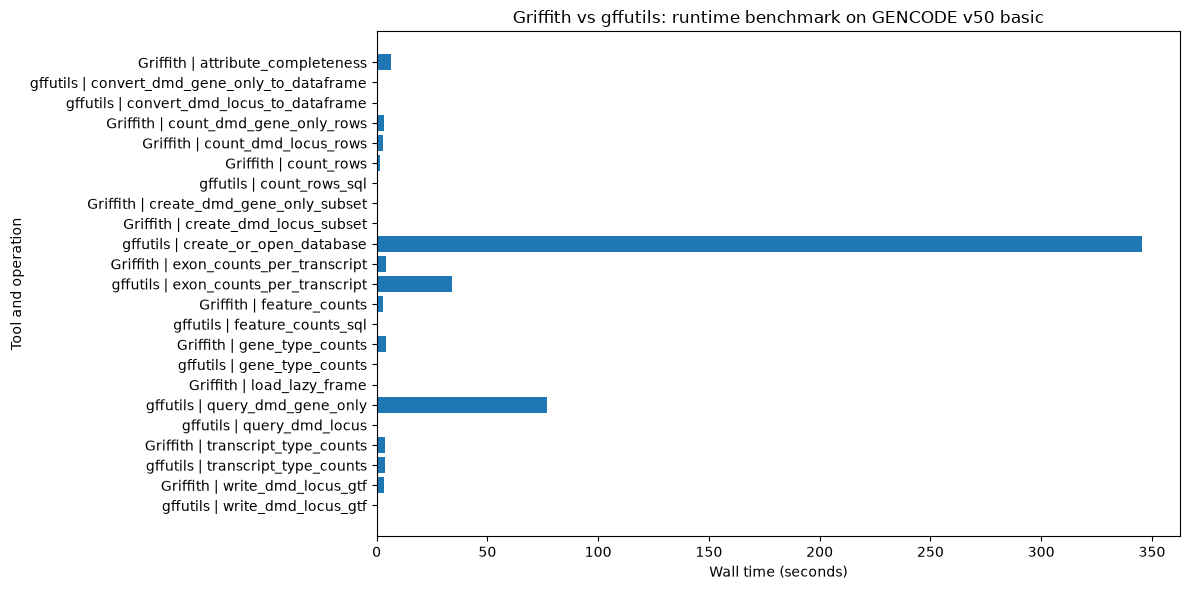

In [13]:
runtime_df = (
    metrics
    .filter(pl.col("success"))
    .sort(["operation", "tool"])
)

plt.figure(figsize=(12, 6))

labels = [
    f"{row['tool']} | {row['operation']}"
    for row in runtime_df.iter_rows(named=True)
]

plt.barh(
    labels[::-1],
    runtime_df["wall_time_sec"].to_list()[::-1],
)

plt.xlabel("Wall time (seconds)")
plt.ylabel("Tool and operation")
plt.title("Griffith vs gffutils: runtime benchmark on GENCODE v50 basic")
plt.tight_layout()
plt.show()

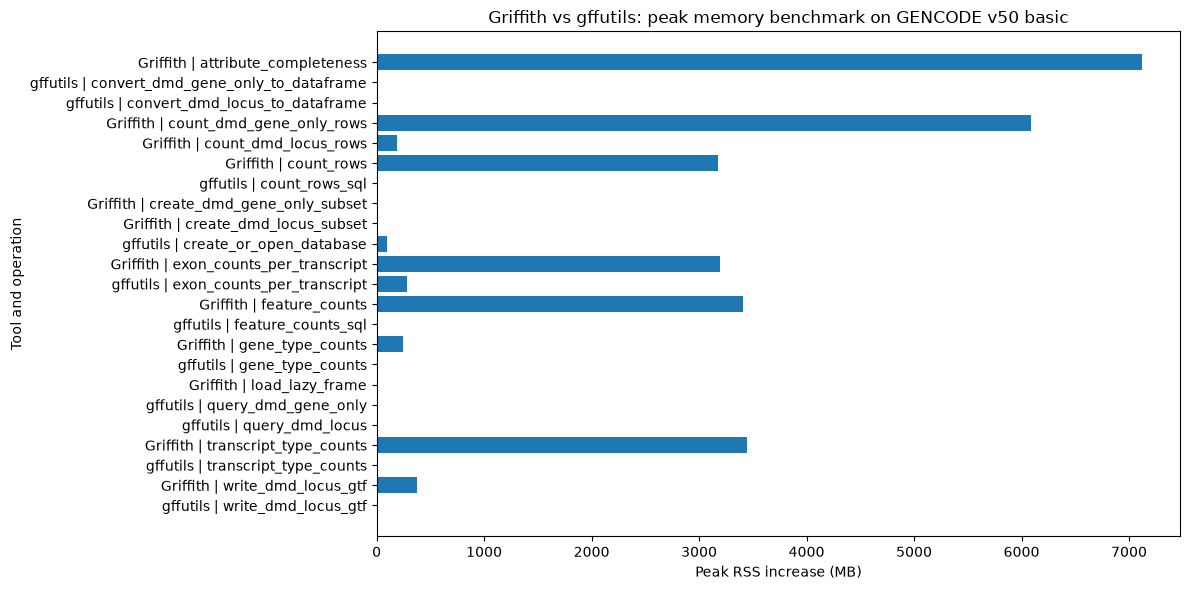

In [14]:
memory_df = (
    metrics
    .filter(pl.col("success"))
    .sort(["operation", "tool"])
)

plt.figure(figsize=(12, 6))

labels = [
    f"{row['tool']} | {row['operation']}"
    for row in memory_df.iter_rows(named=True)
]

plt.barh(
    labels[::-1],
    memory_df["peak_rss_delta_mb"].to_list()[::-1],
)

plt.xlabel("Peak RSS increase (MB)")
plt.ylabel("Tool and operation")
plt.title("Griffith vs gffutils: peak memory benchmark on GENCODE v50 basic")
plt.tight_layout()
plt.show()

In [15]:
OPERATION_MAP = {
    "count_rows": {
        "Griffith": "count_rows",
        "gffutils": "count_rows_sql",
    },
    "feature_counts": {
        "Griffith": "feature_counts",
        "gffutils": "feature_counts_sql",
    },
    "gene_type_counts": {
        "Griffith": "gene_type_counts",
        "gffutils": "gene_type_counts",
    },
    "transcript_type_counts": {
        "Griffith": "transcript_type_counts",
        "gffutils": "transcript_type_counts",
    },
    "exon_counts_per_transcript": {
        "Griffith": "exon_counts_per_transcript",
        "gffutils": "exon_counts_per_transcript",
    },
    "dmd_locus_query": {
        "Griffith": "count_dmd_locus_rows",
        "gffutils": "query_dmd_locus",
    },
    "write_dmd_locus": {
        "Griffith": "write_dmd_locus_gtf",
        "gffutils": "write_dmd_locus_gtf",
    },
}

matched_rows = []

for task, mapping in OPERATION_MAP.items():
    for tool, operation in mapping.items():
        row = (
            metrics
            .filter(
                (pl.col("tool") == tool)
                & (pl.col("operation") == operation)
                & pl.col("success")
            )
        )

        if row.height == 0:
            continue

        r = row.row(0, named=True)

        matched_rows.append(
            {
                "task": task,
                "tool": tool,
                "operation": operation,
                "wall_time_sec": r["wall_time_sec"],
                "peak_rss_delta_mb": r["peak_rss_delta_mb"],
            }
        )

matched = pl.DataFrame(matched_rows)

matched

task,tool,operation,wall_time_sec,peak_rss_delta_mb
str,str,str,f64,f64
"""count_rows""","""Griffith""","""count_rows""",1.666711,3179.636719
"""count_rows""","""gffutils""","""count_rows_sql""",0.01729,1.542969
"""feature_counts""","""Griffith""","""feature_counts""",2.776186,3408.902344
"""feature_counts""","""gffutils""","""feature_counts_sql""",0.235751,1.800781
"""gene_type_counts""","""Griffith""","""gene_type_counts""",4.046641,249.550781
…,…,…,…,…
"""exon_counts_per_transcript""","""gffutils""","""exon_counts_per_transcript""",33.91799,280.046875
"""dmd_locus_query""","""Griffith""","""count_dmd_locus_rows""",2.697301,185.121094
"""dmd_locus_query""","""gffutils""","""query_dmd_locus""",0.033815,3.3515625


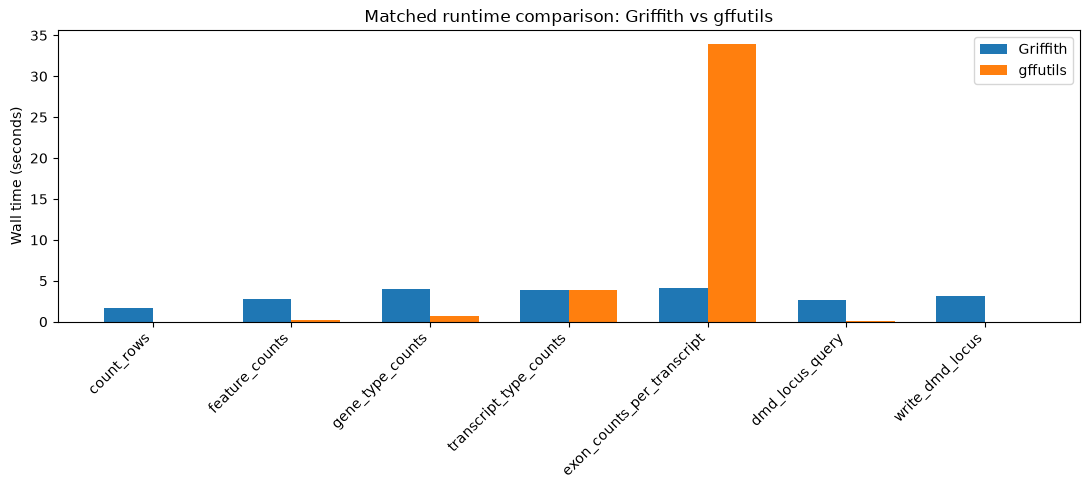

In [16]:
tasks = matched["task"].unique(maintain_order=True).to_list()

x_positions = list(range(len(tasks)))
width = 0.35

griffith_times = []
gffutils_times = []

for task in tasks:
    g_row = matched.filter((pl.col("task") == task) & (pl.col("tool") == "Griffith"))
    u_row = matched.filter((pl.col("task") == task) & (pl.col("tool") == "gffutils"))

    griffith_times.append(g_row["wall_time_sec"][0] if g_row.height else 0)
    gffutils_times.append(u_row["wall_time_sec"][0] if u_row.height else 0)

plt.figure(figsize=(11, 5))

plt.bar(
    [x - width / 2 for x in x_positions],
    griffith_times,
    width=width,
    label="Griffith",
)

plt.bar(
    [x + width / 2 for x in x_positions],
    gffutils_times,
    width=width,
    label="gffutils",
)

plt.xticks(x_positions, tasks, rotation=45, ha="right")
plt.ylabel("Wall time (seconds)")
plt.title("Matched runtime comparison: Griffith vs gffutils")
plt.legend()
plt.tight_layout()
plt.show()

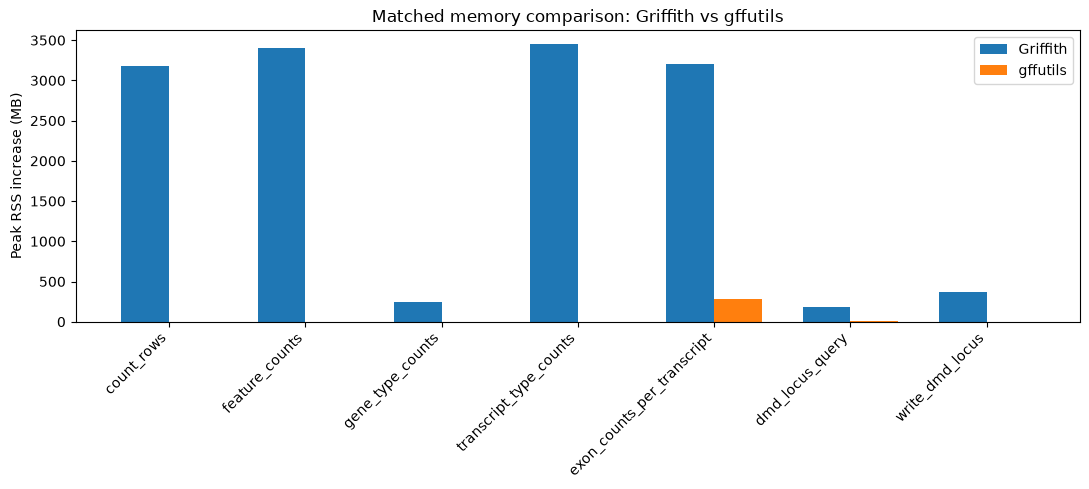

In [17]:
griffith_memory = []
gffutils_memory = []

for task in tasks:
    g_row = matched.filter((pl.col("task") == task) & (pl.col("tool") == "Griffith"))
    u_row = matched.filter((pl.col("task") == task) & (pl.col("tool") == "gffutils"))

    griffith_memory.append(g_row["peak_rss_delta_mb"][0] if g_row.height else 0)
    gffutils_memory.append(u_row["peak_rss_delta_mb"][0] if u_row.height else 0)

plt.figure(figsize=(11, 5))

plt.bar(
    [x - width / 2 for x in x_positions],
    griffith_memory,
    width=width,
    label="Griffith",
)

plt.bar(
    [x + width / 2 for x in x_positions],
    gffutils_memory,
    width=width,
    label="gffutils",
)

plt.xticks(x_positions, tasks, rotation=45, ha="right")
plt.ylabel("Peak RSS increase (MB)")
plt.title("Matched memory comparison: Griffith vs gffutils")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
print("Griffith DMD locus preview")
(
    griffith_dmd_locus.frame
    .select(
        [
            "seqid",
            "source",
            "feature",
            "start",
            "end",
            "strand",
            "gene_id",
            "gene_name",
            "transcript_id",
            "transcript_name",
            "exon_number",
        ]
    )
    .limit(20)
    .collect()
)

Griffith DMD locus preview


seqid,source,feature,start,end,strand,gene_id,gene_name,transcript_id,transcript_name,exon_number
str,str,str,i64,i64,str,str,str,str,str,str
"""chrX""","""HAVANA""","""gene""",31014709,31070685,"""+""","""ENSG00000295010.1""","""ENSG00000295010""",null,null,null
"""chrX""","""HAVANA""","""transcript""",31014709,31070685,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""ENST00000727252.1""","""ENST00000727252""",null
"""chrX""","""HAVANA""","""exon""",31014709,31015108,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""ENST00000727252.1""","""ENST00000727252""","""1"""
"""chrX""","""HAVANA""","""exon""",31049807,31049905,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""ENST00000727252.1""","""ENST00000727252""","""2"""
"""chrX""","""HAVANA""","""exon""",31069524,31069757,"""+""","""ENSG00000295010.1""","""ENSG00000295010""","""ENST00000727252.1""","""ENST00000727252""","""3"""
…,…,…,…,…,…,…,…,…,…,…
"""chrX""","""HAVANA""","""transcript""",31071768,31198592,"""+""","""ENSG00000297249.1""","""ENSG00000297249""","""ENST00000746482.1""","""ENST00000746482""",null
"""chrX""","""HAVANA""","""exon""",31071768,31071848,"""+""","""ENSG00000297249.1""","""ENSG00000297249""","""ENST00000746482.1""","""ENST00000746482""","""1"""
"""chrX""","""HAVANA""","""exon""",31117709,31117854,"""+""","""ENSG00000297249.1""","""ENSG00000297249""","""ENST00000746482.1""","""ENST00000746482""","""2"""


In [19]:
print("gffutils DMD locus preview")
gffutils_dmd_locus_df.head(20)

gffutils DMD locus preview


seqid,source,feature,start,end,score,strand,phase,gene_id,gene_name,gene_type,transcript_id,transcript_name,transcript_type,exon_number,exon_id
str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str
"""chrX""","""HAVANA""","""exon""",31014709,31015108,""".""","""+""",""".""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""1""","""ENSE00004052638.1"""
"""chrX""","""HAVANA""","""gene""",31014709,31070685,""".""","""+""",""".""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""",null,null,null,null,null
"""chrX""","""HAVANA""","""transcript""",31014709,31070685,""".""","""+""",""".""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""",null,null
"""chrX""","""HAVANA""","""exon""",31049807,31049905,""".""","""+""",""".""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""2""","""ENSE00004052640.1"""
"""chrX""","""HAVANA""","""exon""",31069524,31069757,""".""","""+""",""".""","""ENSG00000295010.1""","""ENSG00000295010""","""lncRNA""","""ENST00000727252.1""","""ENST00000727252""","""lncRNA""","""3""","""ENSE00004052641.1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chrX""","""HAVANA""","""start_codon""",31071951,31071953,""".""","""-""","""0""","""ENSG00000132446.7""","""FTHL17""","""protein_coding""","""ENST00000359202.5""","""FTHL17-201""","""protein_coding""","""1""","""ENSE00001431309.5"""
"""chrX""","""HAVANA""","""UTR""",31071954,31072041,""".""","""-""",""".""","""ENSG00000132446.7""","""FTHL17""","""protein_coding""","""ENST00000359202.5""","""FTHL17-201""","""protein_coding""","""1""","""ENSE00001431309.5"""
"""chrX""","""HAVANA""","""gene""",31097677,33339609,""".""","""-""",""".""","""ENSG00000198947.19""","""DMD""","""protein_coding""",null,null,null,null,null


In [20]:
db_size = GFFUTILS_DB.stat().st_size / 1024**2 if GFFUTILS_DB.exists() else None

storage_summary = pl.DataFrame(
    [
        {
            "item": "input_gtf",
            "path": str(GTF_PATH),
            "size_mb": file_size_mb(GTF_PATH),
        },
        {
            "item": "gffutils_sqlite_db",
            "path": str(GFFUTILS_DB),
            "size_mb": db_size,
        },
        {
            "item": "griffith_dmd_locus_gtf",
            "path": str(griffith_dmd_locus_out),
            "size_mb": file_size_mb(griffith_dmd_locus_out) if griffith_dmd_locus_out.exists() else None,
        },
        {
            "item": "gffutils_dmd_locus_gtf",
            "path": str(gffutils_dmd_locus_out),
            "size_mb": file_size_mb(gffutils_dmd_locus_out) if gffutils_dmd_locus_out.exists() else None,
        },
    ]
)

storage_summary

item,path,size_mb
str,str,f64
"""input_gtf""","""../tests/data/gencode.v50.chr_…",3109.718218
"""gffutils_sqlite_db""","""benchmark_gencode_v50_griffith…",6399.851562
"""griffith_dmd_locus_gtf""","""benchmark_gencode_v50_griffith…",0.701584
"""gffutils_dmd_locus_gtf""","""benchmark_gencode_v50_griffith…",0.768219


In [22]:
final_report = (
    metrics
    .filter(pl.col("success"))
    .group_by("tool")
    .agg(
        pl.len().alias("n_successful_operations"),
        pl.sum("wall_time_sec").alias("total_wall_time_sec"),
        pl.max("peak_rss_mb").alias("max_peak_rss_mb"),
        pl.max("peak_rss_delta_mb").alias("max_peak_rss_delta_mb"),
    )
    .with_columns(
        pl.lit(str(GTF_PATH)).alias("input_gtf"),
        pl.lit(file_size_mb(GTF_PATH)).alias("input_gtf_size_mb"),
    )
)

final_report

tool,n_successful_operations,total_wall_time_sec,max_peak_rss_mb,max_peak_rss_delta_mb,input_gtf,input_gtf_size_mb
str,u32,f64,f64,f64,str,f64
"""gffutils""",11,460.913873,1117.863281,280.046875,"""../tests/data/gencode.v50.chr_…",3109.718218
"""Griffith""",12,32.044252,8022.894531,7118.226562,"""../tests/data/gencode.v50.chr_…",3109.718218


## Benchmark interpretation

This benchmark compares Griffith with gffutils on the GENCODE v50 basic human GTF annotation, a large real-world annotation file of approximately 3.1 GB and 7.6 million feature rows.

The two tools produced identical feature-type counts across all major GTF feature classes, including exon, CDS, UTR, transcript, start_codon, stop_codon, gene, and Selenocysteine. This confirms that Griffith correctly parses the global structure of the annotation and produces results consistent with a mature reference library.

The main architectural difference between the tools is important for interpreting the results. Griffith operates directly on the GTF through a Polars-backed dataframe/lazy-frame workflow. gffutils, instead, first imports the annotation into a persistent SQLite database. In this benchmark, Griffith completed the full set of dataframe-style operations in approximately 32 seconds, whereas the gffutils workflow took approximately 461 seconds including database creation/opening. This supports Griffith as a lightweight and fast option for cold-start annotation manipulation workflows where users want to parse, filter, summarize, and export GTF files without building an intermediate database.

However, once the gffutils SQLite database exists, several database-backed queries are faster than the corresponding Griffith operations. For example, row counting, feature counting, and genomic-region queries are extremely fast in gffutils after database creation. Therefore, the benchmark should not be interpreted as showing that Griffith is universally faster than gffutils. Rather, it shows that the two tools are optimized for different use cases: Griffith is better suited to immediate dataframe-oriented manipulation, while gffutils is well suited to repeated, persistent, hierarchy-aware queries after database construction.

Memory usage also differs substantially. Griffith showed higher peak RSS memory usage during some full-file operations, especially operations that force full annotation scans and attribute parsing. This highlights an important practical recommendation: for very large files, Griffith users should prefer lazy filtering, projection, and direct writing of subsets rather than collecting entire annotations into memory.

The DMD locus workflow demonstrates a realistic use case: extracting, inspecting, exporting, and re-reading a biologically meaningful genomic region from a large GTF file. The broad DMD interval captures the DMD genomic region and neighboring annotation context, while the DMD gene-only subset provides a stricter gene-specific extraction.

Overall, this benchmark supports Griffith as a modern, dataframe-first complement to tools such as gffutils. It is not a replacement for all hierarchy-aware database workflows, but it provides a fast and convenient Polars-based API for scalable GTF/GFF annotation engineering.